# Final NIDS Model Evaluation

This notebook evaluates the trained NIDS experiments from saved JSON result files. It does not retrain any model.

Evaluation scope:

- ML baselines: Logistic Regression, Random Forest, XGBoost, LightGBM.
- DL models: MLP, CNN1D, BiLSTM with attention, CNN-LSTM hybrid.
- Datasets: NSL-KDD, UNSW-NB15, CICIDS2017.
- Outputs: final metric table, rankings, per-class metrics, plots, and a markdown summary.

Important note: CICIDS2017 ML may have partial evaluated legacy metrics plus train-only artifacts from the Colab training notebook. Evaluated rows are included in rankings; train-only rows are tracked in the completeness table until prediction/evaluation metrics are produced.

## 1. Locate Project and Results

Run this cell first. It supports both local Windows runs and Google Colab Drive runs.

In [1]:
from pathlib import Path
import os
import sys

IN_COLAB = Path('/content').exists()

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as exc:
        print(f'Colab Drive mount skipped or failed: {exc}')

candidate_project_dirs = [
    Path.cwd(),
    Path.cwd() / 'ids_deep_learning',
    Path('/content/Nids_deep_learning/ids_deep_learning'),
    Path('/content/drive/MyDrive/nids_deep_learning/ids_deep_learning'),
    Path('G:/My Drive/nids_deep_learning/ids_deep_learning'),
]

PROJECT_DIR = None
for candidate in candidate_project_dirs:
    candidate = candidate.resolve() if candidate.exists() else candidate
    if (candidate / 'results').exists() and (candidate / 'src').exists():
        PROJECT_DIR = candidate
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        'Could not locate project directory. Expected a folder containing both results/ and src/.'
    )

os.chdir(PROJECT_DIR)
for path in [PROJECT_DIR, PROJECT_DIR.parent]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

RESULTS_DIR = PROJECT_DIR / 'results'
FINAL_DIR = RESULTS_DIR / 'final_evaluation'
FINAL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project directory: {PROJECT_DIR}')
print(f'Results directory: {RESULTS_DIR}')
print(f'Final evaluation output directory: {FINAL_DIR}')

Project directory: G:\My Drive\nids_deep_learning\ids_deep_learning
Results directory: G:\My Drive\nids_deep_learning\ids_deep_learning\results
Final evaluation output directory: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation


## 2. Imports and Evaluation Configuration

In [2]:
import datetime as dt
import json
import math
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    def display(value):
        print(value)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 120)

DATASET_ORDER = ['nsl_kdd', 'unsw_nb15', 'cicids2017']
DATASET_LABELS = {
    'nsl_kdd': 'NSL-KDD',
    'unsw_nb15': 'UNSW-NB15',
    'cicids2017': 'CICIDS2017',
}

ML_MODELS = ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM']
DL_EXPERIMENTS = [
    'MLP_Modular',
    'CNN1D_Modular',
    'BiLSTMAttention_Modular',
    'CNNLSTMHybrid_Modular',
]

MODEL_LABELS = {
    'LogisticRegression': 'Logistic Regression',
    'RandomForest': 'Random Forest',
    'XGBoost': 'XGBoost',
    'LightGBM': 'LightGBM',
    'MLP_Modular': 'MLP',
    'CNN1D_Modular': 'CNN1D',
    'BiLSTMAttention_Modular': 'BiLSTM Attention',
    'CNNLSTMHybrid_Modular': 'CNN-LSTM Hybrid',
}

FAMILY_COLORS = {
    'ML': '#4C78A8',
    'DL': '#F58518',
}

CICIDS_ML_ZIP_CANDIDATES = [
    Path('/content/drive/MyDrive/nids_outputs/cicids2017_ml_artifacts.zip'),
    Path('/content/cicids2017_ml_artifacts.zip'),
    Path('G:/My Drive/nids_outputs/cicids2017_ml_artifacts.zip'),
    PROJECT_DIR.parent.parent / 'nids_outputs' / 'cicids2017_ml_artifacts.zip',
]

DL_MANIFEST_CANDIDATES = [
    RESULTS_DIR / 'dl_train_only_manifest.json',
    Path('/content/drive/MyDrive/nids_outputs/dl_train_only/dl_train_only_manifest.json'),
    Path('G:/My Drive/nids_outputs/dl_train_only/dl_train_only_manifest.json'),
]

METRIC_COLUMNS = [
    'accuracy',
    'macro_f1',
    'weighted_f1',
    'precision_macro',
    'recall_macro',
    'precision_weighted',
    'recall_weighted',
    'far',
    'roc_auc',
    'pr_auc',
    'min_class_recall',
    'train_seconds',
]

print('Evaluation configuration loaded.')

Evaluation configuration loaded.


## 3. Helper Functions

In [3]:
def load_json(path):
    path = Path(path)
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


def load_json_from_zip(zip_path, member_name):
    with zipfile.ZipFile(zip_path) as archive:
        with archive.open(member_name) as handle:
            return json.loads(handle.read().decode('utf-8'))


def first_existing_path(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    return None


def as_float(value):
    if value is None:
        return np.nan
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    if math.isfinite(value):
        return value
    return np.nan


def friendly_model_name(model_name):
    return MODEL_LABELS.get(model_name, str(model_name))


def classification_report_rows(report):
    if not isinstance(report, dict):
        return []
    rows = []
    for label, values in report.items():
        if label in {'accuracy', 'macro avg', 'weighted avg'}:
            continue
        if isinstance(values, dict) and {'precision', 'recall', 'f1-score'}.issubset(values):
            rows.append((str(label), values))
    return rows


def min_class_recall(metrics):
    recalls = [as_float(values.get('recall')) for _, values in classification_report_rows(metrics.get('classification_report', {}))]
    recalls = [value for value in recalls if not pd.isna(value)]
    return min(recalls) if recalls else np.nan


def report_metric(metrics, section, metric_name):
    report = metrics.get('classification_report', {})
    values = report.get(section, {}) if isinstance(report, dict) else {}
    if isinstance(values, dict):
        return as_float(values.get(metric_name))
    return np.nan


def flatten_result(dataset, family, model_key, metrics, source_file, experiment=None, extra=None):
    extra = extra or {}
    metrics = metrics or {}
    model_label = friendly_model_name(model_key)
    macro_precision = as_float(metrics.get('precision_macro'))
    macro_recall = as_float(metrics.get('recall_macro'))
    weighted_precision = as_float(metrics.get('precision_weighted'))
    weighted_recall = as_float(metrics.get('recall_weighted'))

    if pd.isna(macro_precision):
        macro_precision = report_metric(metrics, 'macro avg', 'precision')
    if pd.isna(macro_recall):
        macro_recall = report_metric(metrics, 'macro avg', 'recall')
    if pd.isna(weighted_precision):
        weighted_precision = report_metric(metrics, 'weighted avg', 'precision')
    if pd.isna(weighted_recall):
        weighted_recall = report_metric(metrics, 'weighted avg', 'recall')

    macro_f1 = as_float(metrics.get('macro_f1'))
    if pd.isna(macro_f1):
        macro_f1 = report_metric(metrics, 'macro avg', 'f1-score')

    weighted_f1 = as_float(metrics.get('weighted_f1'))
    if pd.isna(weighted_f1):
        weighted_f1 = report_metric(metrics, 'weighted avg', 'f1-score')

    train_seconds = as_float(metrics.get('train_seconds'))
    if pd.isna(train_seconds):
        train_seconds = as_float(extra.get('train_seconds'))

    return {
        'dataset': dataset,
        'dataset_label': DATASET_LABELS.get(dataset, dataset),
        'family': family,
        'model': model_label,
        'model_key': model_key,
        'experiment': experiment or model_key,
        'status': extra.get('status', 'evaluated'),
        'source_file': str(source_file),
        'accuracy': as_float(metrics.get('accuracy')),
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'precision_macro': macro_precision,
        'recall_macro': macro_recall,
        'precision_weighted': weighted_precision,
        'recall_weighted': weighted_recall,
        'far': as_float(metrics.get('far')),
        'roc_auc': as_float(metrics.get('roc_auc')),
        'pr_auc': as_float(metrics.get('pr_auc')),
        'min_class_recall': min_class_recall(metrics),
        'train_seconds': train_seconds,
        'checkpoint': metrics.get('checkpoint') or extra.get('checkpoint'),
        'sample_fraction': extra.get('sample_fraction'),
        'has_confusion_matrix': bool(metrics.get('confusion_matrix')),
        'notes': extra.get('notes', ''),
    }


def metric_is_available(value):
    return not pd.isna(as_float(value))

print('Helper functions ready.')

Helper functions ready.


## 4. Load ML and DL Result Files

This section reads saved result JSON files only. Missing files are recorded in the completeness table later.

In [4]:
rows = []
result_payloads = {}
load_messages = []


def manifest_train_seconds(manifest, model_key):
    if not isinstance(manifest, dict):
        return None
    models = manifest.get('models', {})
    if isinstance(models, dict) and isinstance(models.get(model_key), dict):
        return models[model_key].get('train_seconds')
    train_seconds = manifest.get('train_seconds', {})
    if isinstance(train_seconds, dict):
        return train_seconds.get(model_key)
    return None


# ML baselines with completed metrics.
# CICIDS2017 has a legacy modular file with evaluated LogisticRegression/RandomForest metrics;
# use it as fallback when the dedicated ml_baselines JSON is not available.
for dataset in DATASET_ORDER:
    path = RESULTS_DIR / f'{dataset}_multi_ml_baselines.json'
    payload = None
    source_path = path
    selected_models = None
    source_note = ''

    if path.exists():
        payload = load_json(path)
        load_messages.append(f'Loaded ML metrics: {path.name}')
    elif dataset == 'cicids2017':
        legacy_path = RESULTS_DIR / 'cicids2017_multi_modular_results.json'
        if legacy_path.exists():
            payload = load_json(legacy_path)
            source_path = legacy_path
            selected_models = set(ML_MODELS)
            source_note = 'Loaded from legacy modular result file.'
            load_messages.append(f'Loaded CICIDS2017 legacy ML metrics: {legacy_path.name}')

    if payload is None:
        load_messages.append(f'Missing ML metrics: {path.name}')
        continue

    for model_key, metrics in payload.get('models', {}).items():
        if selected_models is not None and model_key not in selected_models:
            continue
        rows.append(flatten_result(
            dataset,
            'ML',
            model_key,
            metrics,
            source_path,
            extra={'notes': source_note} if source_note else None,
        ))
        result_payloads[(dataset, 'ML', friendly_model_name(model_key))] = {
            'payload': payload,
            'metrics': metrics,
            'source_file': source_path,
        }

# CICIDS2017 ML may also have train-only artifacts from Colab.
# Add only missing models as train_only_no_eval so they remain visible but do not enter rankings.
if not (RESULTS_DIR / 'cicids2017_multi_ml_baselines.json').exists():
    manifest = None
    manifest_source = None
    manifest_path = RESULTS_DIR / 'cicids2017_multi_ml_train_only_manifest.json'
    if manifest_path.exists():
        manifest = load_json(manifest_path)
        manifest_source = manifest_path
    else:
        zip_path = first_existing_path(CICIDS_ML_ZIP_CANDIDATES)
        if zip_path is not None:
            with zipfile.ZipFile(zip_path) as archive:
                manifest_members = [
                    name for name in archive.namelist()
                    if name.endswith('cicids2017_multi_ml_train_only_manifest.json')
                ]
            if manifest_members:
                manifest = load_json_from_zip(zip_path, manifest_members[0])
                manifest_source = zip_path

    if manifest is not None:
        for model_key in ML_MODELS:
            already_loaded = any(
                row['dataset'] == 'cicids2017'
                and row['family'] == 'ML'
                and row['model_key'] == model_key
                and row['status'] == 'evaluated'
                for row in rows
            )
            if already_loaded:
                continue
            rows.append(flatten_result(
                'cicids2017',
                'ML',
                model_key,
                {},
                manifest_source,
                extra={
                    'status': 'train_only_no_eval',
                    'train_seconds': manifest_train_seconds(manifest, model_key),
                    'notes': 'Artifact trained, evaluation metrics not found yet.',
                },
            ))
        load_messages.append(f'Loaded CICIDS2017 ML train-only manifest: {manifest_source}')
    else:
        load_messages.append('CICIDS2017 ML metrics or train-only manifest not found.')

# DL modular results.
for dataset in DATASET_ORDER:
    for experiment in DL_EXPERIMENTS:
        path = RESULTS_DIR / f'{dataset}_multi_{experiment}_results.json'
        if not path.exists():
            load_messages.append(f'Missing DL metrics: {path.name}')
            continue
        payload = load_json(path)
        metrics = payload.get('models', {}).get(experiment)
        if metrics is None and payload.get('models'):
            first_key = next(iter(payload['models']))
            metrics = payload['models'][first_key]
        if metrics is None:
            load_messages.append(f'No model metrics inside {path.name}')
            continue
        rows.append(flatten_result(
            dataset,
            'DL',
            experiment,
            metrics,
            path,
            experiment=experiment,
            extra={
                'sample_fraction': payload.get('sample_fraction'),
            },
        ))
        result_payloads[(dataset, 'DL', friendly_model_name(experiment))] = {
            'payload': payload,
            'metrics': metrics,
            'source_file': path,
        }
        load_messages.append(f'Loaded DL metrics: {path.name}')

eval_df = pd.DataFrame(rows)

for message in load_messages:
    print(message)

print(f'\nLoaded rows: {len(eval_df)}')
display(eval_df[['dataset_label', 'family', 'model', 'status', 'accuracy', 'macro_f1', 'weighted_f1', 'far', 'train_seconds']].sort_values(['dataset_label', 'family', 'model']))

Loaded ML metrics: nsl_kdd_multi_ml_baselines.json
Loaded ML metrics: unsw_nb15_multi_ml_baselines.json
Loaded ML metrics: cicids2017_multi_ml_baselines.json
Loaded DL metrics: nsl_kdd_multi_MLP_Modular_results.json
Loaded DL metrics: nsl_kdd_multi_CNN1D_Modular_results.json
Loaded DL metrics: nsl_kdd_multi_BiLSTMAttention_Modular_results.json
Loaded DL metrics: nsl_kdd_multi_CNNLSTMHybrid_Modular_results.json
Loaded DL metrics: unsw_nb15_multi_MLP_Modular_results.json
Loaded DL metrics: unsw_nb15_multi_CNN1D_Modular_results.json
Loaded DL metrics: unsw_nb15_multi_BiLSTMAttention_Modular_results.json
Loaded DL metrics: unsw_nb15_multi_CNNLSTMHybrid_Modular_results.json
Loaded DL metrics: cicids2017_multi_MLP_Modular_results.json
Loaded DL metrics: cicids2017_multi_CNN1D_Modular_results.json
Loaded DL metrics: cicids2017_multi_BiLSTMAttention_Modular_results.json
Loaded DL metrics: cicids2017_multi_CNNLSTMHybrid_Modular_results.json

Loaded rows: 24


,dataset_label,family,model,status,accuracy,macro_f1,weighted_f1,far,train_seconds
22,CICIDS2017,DL,BiLSTM Attention,evaluated,0.961169,0.724753,0.967079,0.046452,4101.881011
23,CICIDS2017,DL,CNN-LSTM Hybrid,evaluated,0.955116,0.589546,0.965502,0.053518,1121.539900
21,CICIDS2017,DL,CNN1D,evaluated,0.960848,0.688094,0.968956,0.046661,654.379724
20,CICIDS2017,DL,MLP,evaluated,0.968573,0.710507,0.976324,0.037577,709.475353
11,CICIDS2017,ML,LightGBM,evaluated,0.373080,0.279609,0.497171,0.673153,621.914017
8,CICIDS2017,ML,Logistic Regression,evaluated,0.859661,0.546000,0.906128,0.167359,876.002552
9,CICIDS2017,ML,Random Forest,evaluated,0.998551,0.976169,0.998542,0.000699,1703.975228
10,CICIDS2017,ML,XGBoost,evaluated,0.998876,0.892134,0.998873,0.000925,797.295189
14,NSL-KDD,DL,BiLSTM Attention,evaluated,0.964755,0.720592,0.968754,0.058133,105.529815
15,NSL-KDD,DL,CNN-LSTM Hybrid,evaluated,0.981544,0.758531,0.983413,0.019155,35.694812


## 5. Completeness Check

A complete final evaluation should have all expected model-dataset combinations either evaluated or explicitly marked as train-only.

In [5]:
expected_rows = []
for dataset in DATASET_ORDER:
    for model_key in ML_MODELS:
        expected_rows.append({
            'dataset': dataset,
            'dataset_label': DATASET_LABELS[dataset],
            'family': 'ML',
            'model': friendly_model_name(model_key),
            'model_key': model_key,
        })
    for experiment in DL_EXPERIMENTS:
        expected_rows.append({
            'dataset': dataset,
            'dataset_label': DATASET_LABELS[dataset],
            'family': 'DL',
            'model': friendly_model_name(experiment),
            'model_key': experiment,
        })

expected_df = pd.DataFrame(expected_rows)

if eval_df.empty:
    completeness_df = expected_df.copy()
    completeness_df['status'] = 'missing'
else:
    completeness_df = expected_df.merge(
        eval_df[['dataset', 'family', 'model', 'status', 'accuracy', 'macro_f1', 'weighted_f1', 'far', 'source_file']],
        on=['dataset', 'family', 'model'],
        how='left',
    )
    completeness_df['status'] = completeness_df['status'].fillna('missing')

completeness_df['has_metrics'] = completeness_df['macro_f1'].apply(metric_is_available)
status_summary = completeness_df.groupby(['dataset_label', 'family', 'status']).size().reset_index(name='count')

print('Completeness summary:')
display(status_summary)

display(completeness_df.sort_values(['dataset_label', 'family', 'model']))

Completeness summary:


,dataset_label,family,status,count
0,CICIDS2017,DL,evaluated,4
1,CICIDS2017,ML,evaluated,4
2,NSL-KDD,DL,evaluated,4
3,NSL-KDD,ML,evaluated,4
4,UNSW-NB15,DL,evaluated,4
5,UNSW-NB15,ML,evaluated,4


,dataset,dataset_label,family,model,model_key,status,accuracy,macro_f1,weighted_f1,far,source_file,has_metrics
22,cicids2017,CICIDS2017,DL,BiLSTM Attention,BiLSTMAttention_Modular,evaluated,0.961169,0.724753,0.967079,0.046452,G:\My Drive\nids_deep_learning\ids_deep_learning\results\cicids2017_multi_BiLSTMAttention_Modular_results.json,True
23,cicids2017,CICIDS2017,DL,CNN-LSTM Hybrid,CNNLSTMHybrid_Modular,evaluated,0.955116,0.589546,0.965502,0.053518,G:\My Drive\nids_deep_learning\ids_deep_learning\results\cicids2017_multi_CNNLSTMHybrid_Modular_results.json,True
21,cicids2017,CICIDS2017,DL,CNN1D,CNN1D_Modular,evaluated,0.960848,0.688094,0.968956,0.046661,G:\My Drive\nids_deep_learning\ids_deep_learning\results\cicids2017_multi_CNN1D_Modular_results.json,True
20,cicids2017,CICIDS2017,DL,MLP,MLP_Modular,evaluated,0.968573,0.710507,0.976324,0.037577,G:\My Drive\nids_deep_learning\ids_deep_learning\results\cicids2017_multi_MLP_Modular_results.json,True
19,cicids2017,CICIDS2017,ML,LightGBM,LightGBM,evaluated,0.373080,0.279609,0.497171,0.673153,G:\My Drive\nids_deep_learning\ids_deep_learning\results\cicids2017_multi_ml_baselines.json,True
16,cicids2017,CICIDS2017,ML,Logistic Regression,LogisticRegression,evaluated,0.859661,0.546000,0.906128,0.167359,G:\My Drive\nids_deep_learning\ids_deep_learning\results\cicids2017_multi_ml_baselines.json,True
17,cicids2017,CICIDS2017,ML,Random Forest,RandomForest,evaluated,0.998551,0.976169,0.998542,0.000699,G:\My Drive\nids_deep_learning\ids_deep_learning\results\cicids2017_multi_ml_baselines.json,True
18,cicids2017,CICIDS2017,ML,XGBoost,XGBoost,evaluated,0.998876,0.892134,0.998873,0.000925,G:\My Drive\nids_deep_learning\ids_deep_learning\results\cicids2017_multi_ml_baselines.json,True
6,nsl_kdd,NSL-KDD,DL,BiLSTM Attention,BiLSTMAttention_Modular,evaluated,0.964755,0.720592,0.968754,0.058133,G:\My Drive\nids_deep_learning\ids_deep_learning\results\nsl_kdd_multi_BiLSTMAttention_Modular_results.json,True
7,nsl_kdd,NSL-KDD,DL,CNN-LSTM Hybrid,CNNLSTMHybrid_Modular,evaluated,0.981544,0.758531,0.983413,0.019155,G:\My Drive\nids_deep_learning\ids_deep_learning\results\nsl_kdd_multi_CNNLSTMHybrid_Modular_results.json,True


## 6. Final Evaluation Table and Rankings

In [6]:
if eval_df.empty:
    raise RuntimeError('No result rows were loaded. Check RESULTS_DIR and rerun previous cells.')

sort_columns = ['dataset', 'family', 'model']
eval_df = eval_df.sort_values(sort_columns).reset_index(drop=True)

evaluation_csv = FINAL_DIR / 'final_model_evaluation.csv'
eval_df.to_csv(evaluation_csv, index=False)

evaluated_df = eval_df[(eval_df['status'] == 'evaluated') & eval_df['macro_f1'].notna()].copy()

ranking_df = evaluated_df.sort_values(
    ['dataset', 'macro_f1', 'weighted_f1', 'far'],
    ascending=[True, False, False, True],
).copy()
ranking_df['rank_macro_f1'] = ranking_df.groupby('dataset')['macro_f1'].rank(method='min', ascending=False).astype(int)
ranking_df['rank_low_far'] = ranking_df.groupby('dataset')['far'].rank(method='min', ascending=True).astype(int)
ranking_df['rank_weighted_f1'] = ranking_df.groupby('dataset')['weighted_f1'].rank(method='min', ascending=False).astype(int)

ranking_csv = FINAL_DIR / 'final_model_ranking.csv'
ranking_df.to_csv(ranking_csv, index=False)

print(f'Saved final evaluation table: {evaluation_csv}')
print(f'Saved final ranking table: {ranking_csv}')

display(ranking_df[[
    'dataset_label', 'family', 'model', 'rank_macro_f1', 'rank_low_far',
    'accuracy', 'macro_f1', 'weighted_f1', 'far', 'roc_auc', 'pr_auc', 'train_seconds'
]].sort_values(['dataset_label', 'rank_macro_f1']))

Saved final evaluation table: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\final_model_evaluation.csv
Saved final ranking table: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\final_model_ranking.csv


,dataset_label,family,model,rank_macro_f1,rank_low_far,accuracy,macro_f1,weighted_f1,far,roc_auc,pr_auc,train_seconds
6,CICIDS2017,ML,Random Forest,1,1,0.998551,0.976169,0.998542,0.000699,0.999656,0.990784,1703.975228
7,CICIDS2017,ML,XGBoost,2,2,0.998876,0.892134,0.998873,0.000925,0.983099,0.914399,797.295189
0,CICIDS2017,DL,BiLSTM Attention,3,4,0.961169,0.724753,0.967079,0.046452,0.999377,0.866182,4101.881011
3,CICIDS2017,DL,MLP,4,3,0.968573,0.710507,0.976324,0.037577,0.999350,0.838608,709.475353
2,CICIDS2017,DL,CNN1D,5,5,0.960848,0.688094,0.968956,0.046661,0.998601,0.838104,654.379724
1,CICIDS2017,DL,CNN-LSTM Hybrid,6,6,0.955116,0.589546,0.965502,0.053518,0.998950,0.830924,1121.539900
5,CICIDS2017,ML,Logistic Regression,7,7,0.859661,0.546000,0.906128,0.167359,0.997019,0.687408,876.002552
4,CICIDS2017,ML,LightGBM,8,8,0.373080,0.279609,0.497171,0.673153,0.790947,0.239605,621.914017
12,NSL-KDD,ML,LightGBM,1,3,0.999206,0.965769,0.999203,0.000520,0.998370,0.952979,20.735496
15,NSL-KDD,ML,XGBoost,2,2,0.998928,0.955561,0.998927,0.000445,0.999730,0.950211,5.832385


## 7. Best Models by Dataset and Family

In [7]:
best_by_dataset = (
    ranking_df.sort_values(['dataset', 'rank_macro_f1'])
    .groupby('dataset', as_index=False)
    .first()
)

best_by_family = (
    ranking_df.sort_values(['dataset', 'family', 'rank_macro_f1'])
    .groupby(['dataset', 'family'], as_index=False)
    .first()
)

comparison_rows = []
for dataset in DATASET_ORDER:
    subset = best_by_family[best_by_family['dataset'] == dataset]
    ml = subset[subset['family'] == 'ML']
    dl = subset[subset['family'] == 'DL']
    comparison_rows.append({
        'dataset': dataset,
        'dataset_label': DATASET_LABELS[dataset],
        'best_ml_model': ml.iloc[0]['model'] if not ml.empty else None,
        'best_ml_macro_f1': ml.iloc[0]['macro_f1'] if not ml.empty else np.nan,
        'best_dl_model': dl.iloc[0]['model'] if not dl.empty else None,
        'best_dl_macro_f1': dl.iloc[0]['macro_f1'] if not dl.empty else np.nan,
        'macro_f1_gap_dl_minus_ml': (
            (dl.iloc[0]['macro_f1'] - ml.iloc[0]['macro_f1'])
            if not ml.empty and not dl.empty else np.nan
        ),
    })

family_comparison_df = pd.DataFrame(comparison_rows)
family_comparison_csv = FINAL_DIR / 'final_ml_vs_dl_comparison.csv'
family_comparison_df.to_csv(family_comparison_csv, index=False)

print('Best model per dataset:')
display(best_by_dataset[['dataset_label', 'family', 'model', 'macro_f1', 'weighted_f1', 'far', 'accuracy']])

print('Best ML vs best DL:')
display(family_comparison_df)

print(f'Saved ML vs DL comparison: {family_comparison_csv}')

Best model per dataset:


,dataset_label,family,model,macro_f1,weighted_f1,far,accuracy
0,CICIDS2017,ML,Random Forest,0.976169,0.998542,0.000699,0.998551
1,NSL-KDD,ML,LightGBM,0.965769,0.999203,0.000520,0.999206
2,UNSW-NB15,ML,LightGBM,0.553633,0.881651,0.034790,0.876128


Best ML vs best DL:


,dataset,dataset_label,best_ml_model,best_ml_macro_f1,best_dl_model,best_dl_macro_f1,macro_f1_gap_dl_minus_ml
0,nsl_kdd,NSL-KDD,LightGBM,0.965769,CNN1D,0.781090,-0.184678
1,unsw_nb15,UNSW-NB15,LightGBM,0.553633,MLP,0.475894,-0.077739
2,cicids2017,CICIDS2017,Random Forest,0.976169,BiLSTM Attention,0.724753,-0.251415


Saved ML vs DL comparison: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\final_ml_vs_dl_comparison.csv


## 8. Visual Comparison

Saved plot: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\macro_f1_by_model.png
Saved plot: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\weighted_f1_by_model.png
Saved plot: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\far_by_model.png


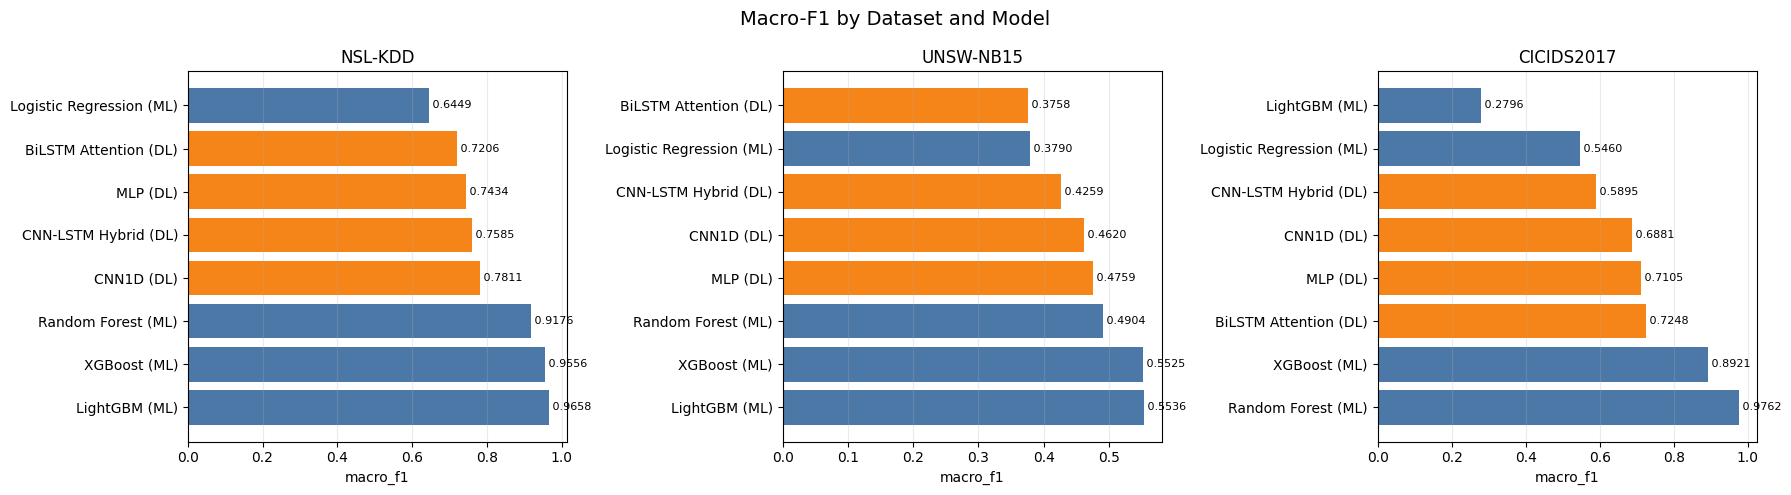

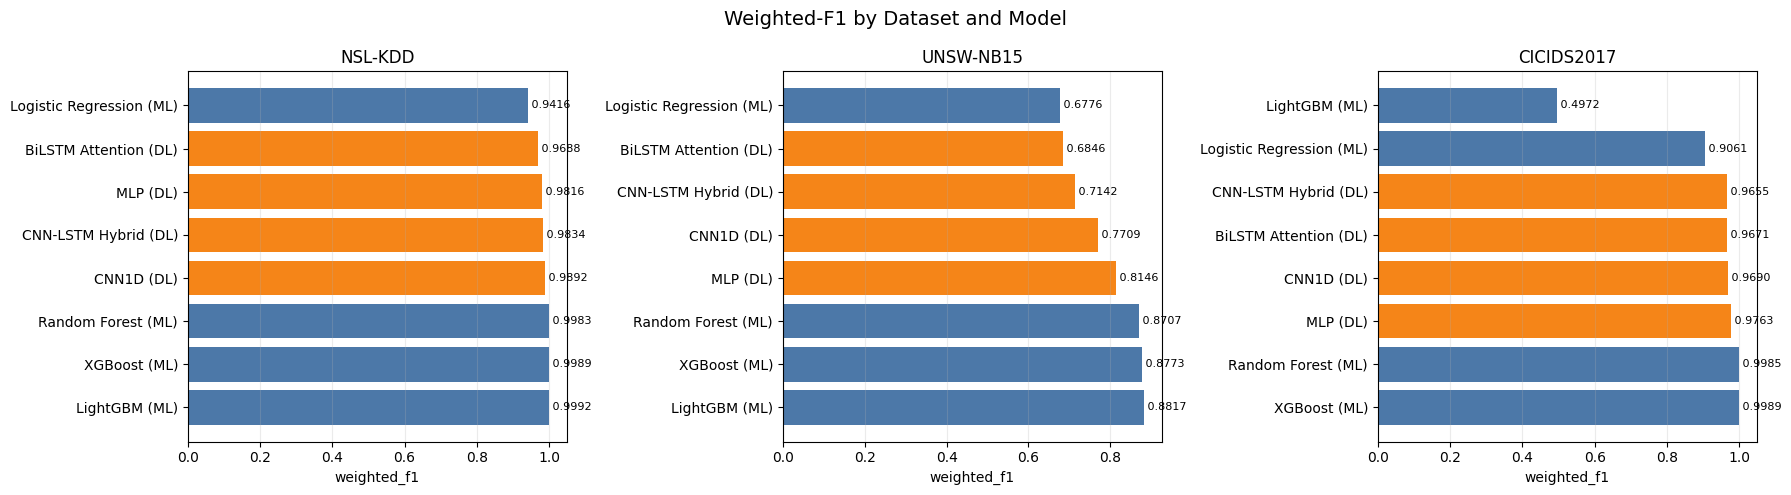

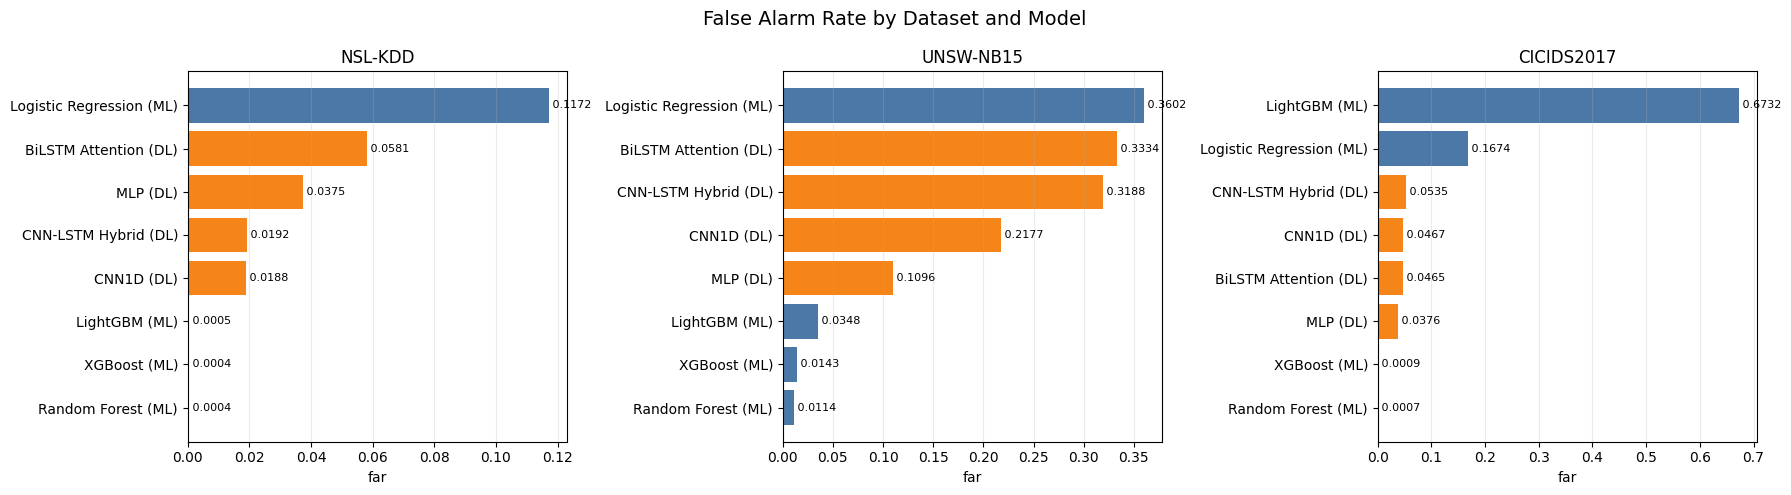

In [8]:
def plot_grouped_metric(df, metric, title, filename, higher_is_better=True):
    data = df[df[metric].notna()].copy()
    if data.empty:
        print(f'Skipped {metric}: no available values.')
        return None

    fig, axes = plt.subplots(1, len(DATASET_ORDER), figsize=(18, 5), sharex=False)
    if len(DATASET_ORDER) == 1:
        axes = [axes]

    for axis, dataset in zip(axes, DATASET_ORDER):
        subset = data[data['dataset'] == dataset].copy()
        if subset.empty:
            axis.set_title(DATASET_LABELS[dataset])
            axis.text(0.5, 0.5, 'No evaluated rows', ha='center', va='center')
            axis.axis('off')
            continue
        subset = subset.sort_values(metric, ascending=not higher_is_better)
        colors = [FAMILY_COLORS.get(family, '#999999') for family in subset['family']]
        labels = [f'{model} ({family})' for model, family in zip(subset['model'], subset['family'])]
        axis.barh(labels, subset[metric], color=colors)
        axis.set_title(DATASET_LABELS[dataset])
        axis.set_xlabel(metric)
        axis.grid(axis='x', alpha=0.25)
        for index, value in enumerate(subset[metric]):
            axis.text(value, index, f' {value:.4f}', va='center', fontsize=8)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    output_path = FINAL_DIR / filename
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Saved plot: {output_path}')
    return fig

plot_grouped_metric(ranking_df, 'macro_f1', 'Macro-F1 by Dataset and Model', 'macro_f1_by_model.png', higher_is_better=True)
plot_grouped_metric(ranking_df, 'weighted_f1', 'Weighted-F1 by Dataset and Model', 'weighted_f1_by_model.png', higher_is_better=True)
plot_grouped_metric(ranking_df, 'far', 'False Alarm Rate by Dataset and Model', 'far_by_model.png', higher_is_better=False)
plt.show()

Saved heatmap: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\macro_f1_heatmap.png


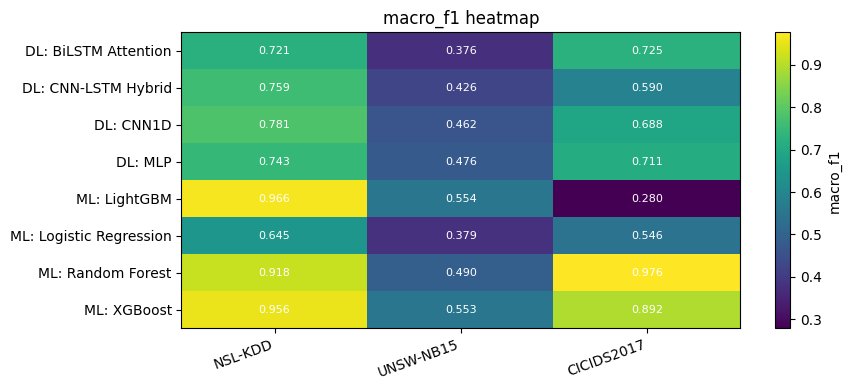

In [9]:
def plot_metric_heatmap(df, metric, filename):
    data = df[df[metric].notna()].copy()
    if data.empty:
        print(f'Skipped heatmap for {metric}: no values.')
        return None

    data['model_family'] = data['family'] + ': ' + data['model']
    pivot = data.pivot_table(index='model_family', columns='dataset_label', values=metric, aggfunc='max')
    pivot = pivot.reindex(columns=[DATASET_LABELS[d] for d in DATASET_ORDER])

    fig, axis = plt.subplots(figsize=(9, max(4, 0.45 * len(pivot))))
    matrix = pivot.to_numpy(dtype=float)
    image = axis.imshow(matrix, aspect='auto', cmap='viridis')
    axis.set_xticks(range(len(pivot.columns)))
    axis.set_xticklabels(pivot.columns, rotation=20, ha='right')
    axis.set_yticks(range(len(pivot.index)))
    axis.set_yticklabels(pivot.index)
    axis.set_title(f'{metric} heatmap')

    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            if not np.isnan(value):
                axis.text(column_index, row_index, f'{value:.3f}', ha='center', va='center', color='white', fontsize=8)

    fig.colorbar(image, ax=axis, label=metric)
    fig.tight_layout()
    output_path = FINAL_DIR / filename
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Saved heatmap: {output_path}')
    return fig

plot_metric_heatmap(ranking_df, 'macro_f1', 'macro_f1_heatmap.png')
plt.show()

Saved scatter plot: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\macro_f1_vs_far.png


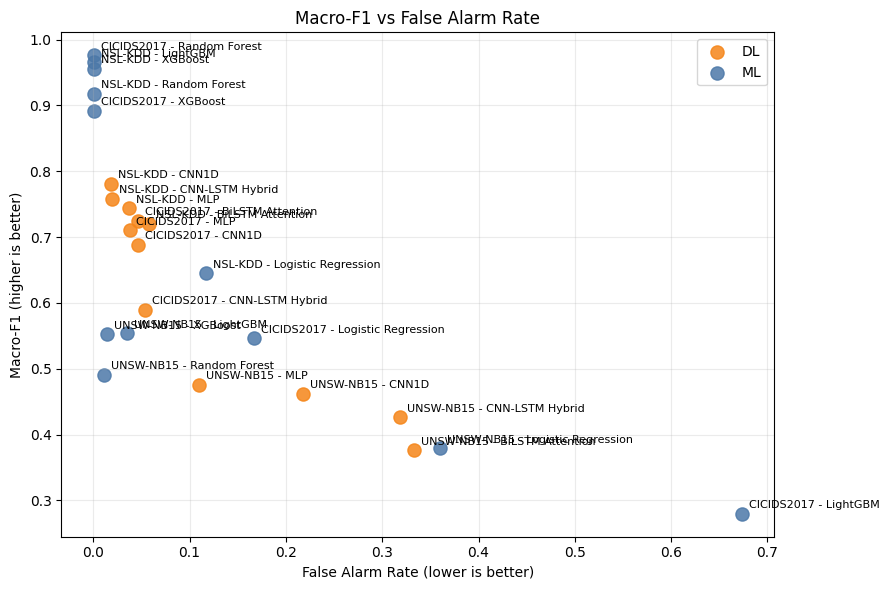

In [10]:
scatter_data = ranking_df[ranking_df['macro_f1'].notna() & ranking_df['far'].notna()].copy()

if scatter_data.empty:
    print('Skipped macro-F1 vs FAR scatter: no complete rows.')
else:
    fig, axis = plt.subplots(figsize=(9, 6))
    for family, group in scatter_data.groupby('family'):
        axis.scatter(
            group['far'],
            group['macro_f1'],
            s=90,
            color=FAMILY_COLORS.get(family, '#999999'),
            label=family,
            alpha=0.85,
        )
        for _, row in group.iterrows():
            axis.annotate(
                f"{row['dataset_label']} - {row['model']}",
                (row['far'], row['macro_f1']),
                textcoords='offset points',
                xytext=(5, 4),
                fontsize=8,
            )
    axis.set_xlabel('False Alarm Rate (lower is better)')
    axis.set_ylabel('Macro-F1 (higher is better)')
    axis.set_title('Macro-F1 vs False Alarm Rate')
    axis.grid(alpha=0.25)
    axis.legend()
    fig.tight_layout()
    output_path = FINAL_DIR / 'macro_f1_vs_far.png'
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Saved scatter plot: {output_path}')
    plt.show()

## 9. Per-Class Metrics

This table extracts per-class precision, recall, and F1 from each evaluated result file when `classification_report` is available.

In [11]:
per_class_rows = []

for _, row in evaluated_df.iterrows():
    key = (row['dataset'], row['family'], row['model'])
    entry = result_payloads.get(key)
    if not entry:
        continue
    report = entry['metrics'].get('classification_report', {})
    label_mapping = entry['payload'].get('label_mapping', {})
    inverse_label_mapping = {str(value): label for label, value in label_mapping.items()}

    for class_id, values in classification_report_rows(report):
        per_class_rows.append({
            'dataset': row['dataset'],
            'dataset_label': row['dataset_label'],
            'family': row['family'],
            'model': row['model'],
            'class_id': class_id,
            'class_label': inverse_label_mapping.get(class_id, class_id),
            'precision': as_float(values.get('precision')),
            'recall': as_float(values.get('recall')),
            'f1_score': as_float(values.get('f1-score')),
            'support': as_float(values.get('support')),
        })

per_class_df = pd.DataFrame(per_class_rows)
per_class_csv = FINAL_DIR / 'final_per_class_metrics.csv'
per_class_df.to_csv(per_class_csv, index=False)

print(f'Saved per-class metrics: {per_class_csv}')
if per_class_df.empty:
    print('No per-class metrics were found.')
else:
    display(per_class_df.sort_values(['dataset_label', 'family', 'model', 'class_label']).head(80))

Saved per-class metrics: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\final_per_class_metrics.csv


,dataset,dataset_label,family,model,class_id,class_label,precision,recall,f1_score,support
0,cicids2017,CICIDS2017,DL,BiLSTM Attention,0,Benign,0.999907,0.953548,0.976178,419297.0
1,cicids2017,CICIDS2017,DL,BiLSTM Attention,1,Botnet,0.076969,1.000000,0.142935,391.0
2,cicids2017,CICIDS2017,DL,BiLSTM Attention,2,BruteForce,0.968306,0.968306,0.968306,1830.0
3,cicids2017,CICIDS2017,DL,BiLSTM Attention,3,DDoS,0.921385,0.999766,0.958976,25603.0
4,cicids2017,CICIDS2017,DL,BiLSTM Attention,4,DoS,0.894621,0.999252,0.944046,38750.0
...,...,...,...,...,...,...,...,...,...,...
75,nsl_kdd,NSL-KDD,DL,BiLSTM Attention,3,R2L,0.483544,0.959799,0.643098,199.0
76,nsl_kdd,NSL-KDD,DL,BiLSTM Attention,4,U2R,0.051471,0.700000,0.095890,10.0
77,nsl_kdd,NSL-KDD,DL,CNN-LSTM Hybrid,0,Benign,0.986043,0.980845,0.983437,13469.0
78,nsl_kdd,NSL-KDD,DL,CNN-LSTM Hybrid,1,DoS,0.996188,0.995754,0.995971,9186.0


## 10. Confusion Matrices for Best Models

The confusion matrices below are plotted for the top macro-F1 model on each dataset.

Saved confusion matrix: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\confusion_matrix_cicids2017_ml_RandomForest.png
Saved confusion matrix: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\confusion_matrix_nsl_kdd_ml_LightGBM.png
Saved confusion matrix: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\confusion_matrix_unsw_nb15_ml_LightGBM.png


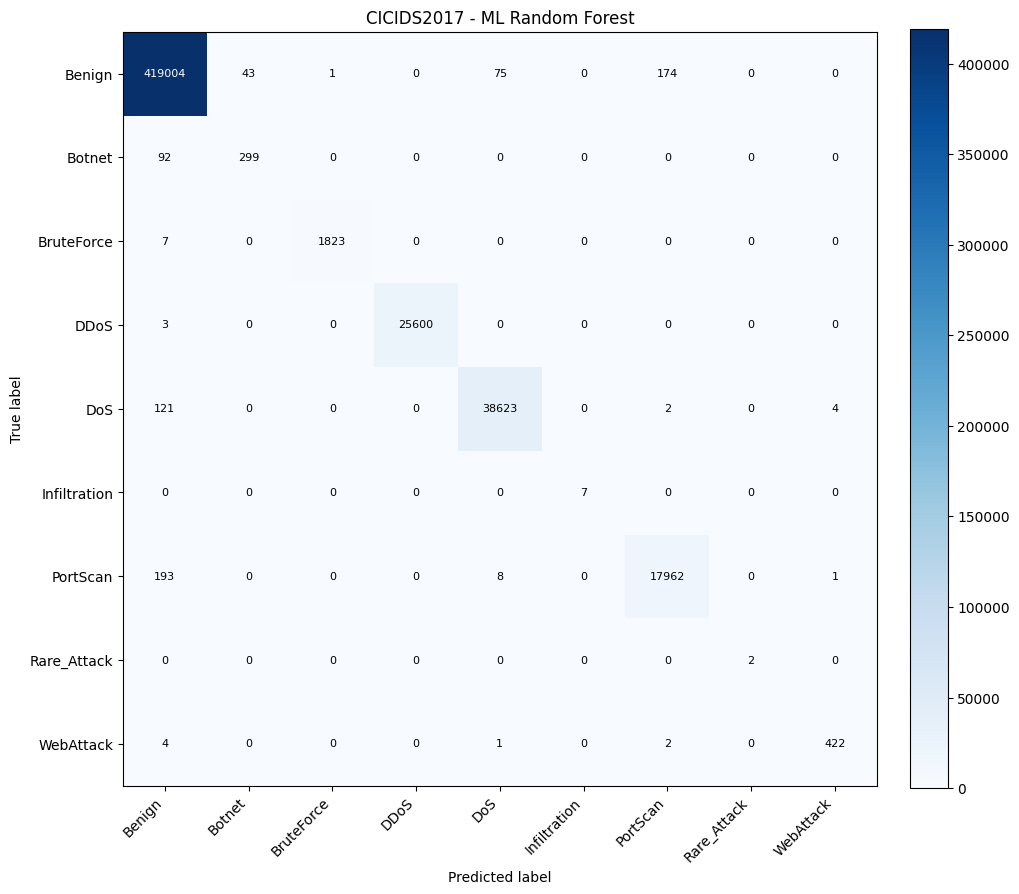

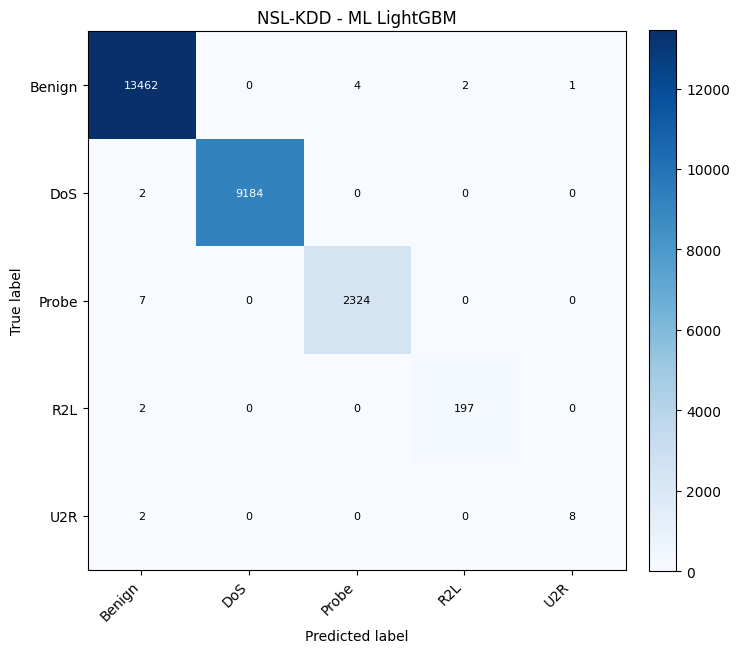

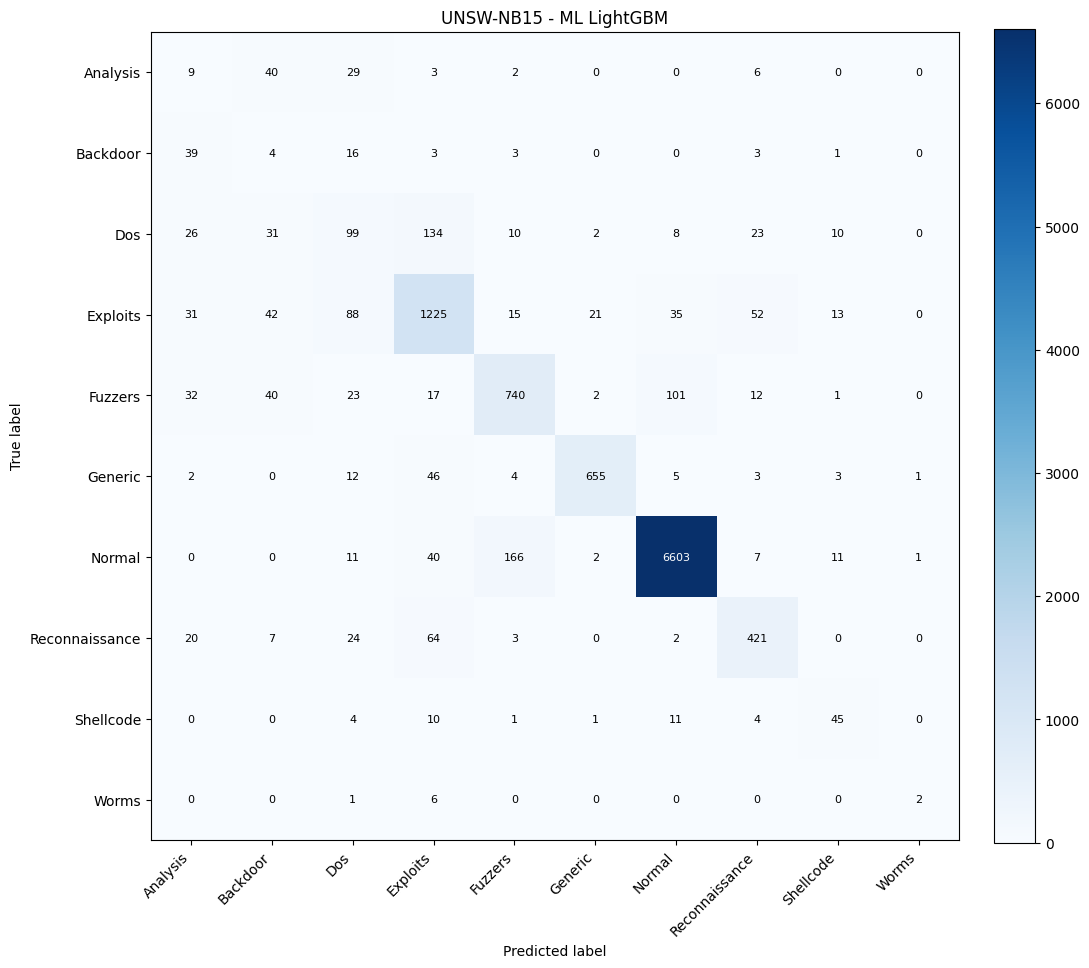

In [12]:
def plot_confusion_matrix_for_row(row):
    key = (row['dataset'], row['family'], row['model'])
    entry = result_payloads.get(key)
    if not entry:
        print(f"No payload found for {row['dataset_label']} {row['model']}.")
        return None

    metrics = entry['metrics']
    matrix = metrics.get('confusion_matrix')
    if matrix is None:
        print(f"No confusion matrix for {row['dataset_label']} {row['model']}.")
        return None

    matrix = np.asarray(matrix)
    label_mapping = entry['payload'].get('label_mapping', {})
    inverse_label_mapping = {int(value): label for label, value in label_mapping.items()}
    labels = [inverse_label_mapping.get(index, str(index)) for index in range(matrix.shape[0])]

    fig_size = max(6, min(12, 0.7 * len(labels) + 4))
    fig, axis = plt.subplots(figsize=(fig_size, fig_size))
    image = axis.imshow(matrix, cmap='Blues')
    axis.set_title(f"{row['dataset_label']} - {row['family']} {row['model']}")
    axis.set_xlabel('Predicted label')
    axis.set_ylabel('True label')
    axis.set_xticks(range(len(labels)))
    axis.set_yticks(range(len(labels)))
    axis.set_xticklabels(labels, rotation=45, ha='right')
    axis.set_yticklabels(labels)

    threshold = matrix.max() / 2 if matrix.size else 0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            color = 'white' if value > threshold else 'black'
            axis.text(j, i, str(value), ha='center', va='center', color=color, fontsize=8)

    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    fig.tight_layout()
    filename = f"confusion_matrix_{row['dataset']}_{row['family'].lower()}_{row['model_key']}.png".replace(' ', '_')
    output_path = FINAL_DIR / filename
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Saved confusion matrix: {output_path}')
    return fig

if best_by_dataset.empty:
    print('No evaluated best models available for confusion matrices.')
else:
    for _, row in best_by_dataset.iterrows():
        plot_confusion_matrix_for_row(row)
    plt.show()

## 11. Generate Markdown Evaluation Summary

In [13]:
def fmt_metric(value, digits=4):
    value = as_float(value)
    if pd.isna(value):
        return 'N/A'
    return f'{value:.{digits}f}'


def build_summary_markdown():
    generated_at = dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    lines = [
        '# Final Model Evaluation Summary',
        '',
        f'Generated at: {generated_at}',
        '',
        '## Coverage',
        '',
    ]

    coverage = completeness_df.groupby(['dataset_label', 'family', 'status']).size().reset_index(name='count')
    for _, row in coverage.iterrows():
        lines.append(f"- {row['dataset_label']} {row['family']}: {row['status']} = {row['count']}")

    lines.extend(['', '## Best Model by Dataset', ''])
    for dataset in DATASET_ORDER:
        subset = best_by_dataset[best_by_dataset['dataset'] == dataset]
        if subset.empty:
            lines.append(f'- {DATASET_LABELS[dataset]}: no evaluated model available.')
            continue
        row = subset.iloc[0]
        lines.append(
            f"- {row['dataset_label']}: {row['family']} {row['model']} "
            f"with macro-F1 {fmt_metric(row['macro_f1'])}, weighted-F1 {fmt_metric(row['weighted_f1'])}, "
            f"accuracy {fmt_metric(row['accuracy'])}, FAR {fmt_metric(row['far'])}."
        )

    lines.extend(['', '## Best ML vs Best DL', ''])
    for _, row in family_comparison_df.iterrows():
        gap = row['macro_f1_gap_dl_minus_ml']
        gap_text = fmt_metric(gap)
        if pd.isna(as_float(gap)):
            interpretation = 'comparison unavailable because one side has no evaluated metric.'
        elif gap > 0:
            interpretation = 'DL is ahead by macro-F1.'
        elif gap < 0:
            interpretation = 'ML is ahead by macro-F1.'
        else:
            interpretation = 'ML and DL are tied by macro-F1.'
        lines.append(
            f"- {row['dataset_label']}: best ML = {row['best_ml_model']} ({fmt_metric(row['best_ml_macro_f1'])}); "
            f"best DL = {row['best_dl_model']} ({fmt_metric(row['best_dl_macro_f1'])}); "
            f"DL minus ML gap = {gap_text}. {interpretation}"
        )

    incomplete = completeness_df[completeness_df['status'] != 'evaluated'].copy()
    lines.extend(['', '## Missing or Train-Only Items', ''])
    if incomplete.empty:
        lines.append('- All expected model-dataset combinations have evaluation metrics.')
    else:
        for _, row in incomplete.sort_values(['dataset_label', 'family', 'model']).iterrows():
            lines.append(f"- {row['dataset_label']} {row['family']} {row['model']}: {row['status']}.")

    lines.extend([
        '',
        '## Output Files',
        '',
        f'- Final evaluation table: `{evaluation_csv}`',
        f'- Ranking table: `{ranking_csv}`',
        f'- Per-class metrics: `{per_class_csv}`',
        f'- ML vs DL comparison: `{family_comparison_csv}`',
    ])

    return '\n'.join(lines)

summary_text = build_summary_markdown()
summary_path = FINAL_DIR / 'final_evaluation_summary.md'
summary_path.write_text(summary_text, encoding='utf-8')

print(f'Saved markdown summary: {summary_path}')
if Markdown is not None:
    display(Markdown(summary_text))
else:
    print(summary_text)

Saved markdown summary: G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\final_evaluation_summary.md


# Final Model Evaluation Summary

Generated at: 2026-07-10 11:21:44

## Coverage

- CICIDS2017 DL: evaluated = 4
- CICIDS2017 ML: evaluated = 4
- NSL-KDD DL: evaluated = 4
- NSL-KDD ML: evaluated = 4
- UNSW-NB15 DL: evaluated = 4
- UNSW-NB15 ML: evaluated = 4

## Best Model by Dataset

- NSL-KDD: ML LightGBM with macro-F1 0.9658, weighted-F1 0.9992, accuracy 0.9992, FAR 0.0005.
- UNSW-NB15: ML LightGBM with macro-F1 0.5536, weighted-F1 0.8817, accuracy 0.8761, FAR 0.0348.
- CICIDS2017: ML Random Forest with macro-F1 0.9762, weighted-F1 0.9985, accuracy 0.9986, FAR 0.0007.

## Best ML vs Best DL

- NSL-KDD: best ML = LightGBM (0.9658); best DL = CNN1D (0.7811); DL minus ML gap = -0.1847. ML is ahead by macro-F1.
- UNSW-NB15: best ML = LightGBM (0.5536); best DL = MLP (0.4759); DL minus ML gap = -0.0777. ML is ahead by macro-F1.
- CICIDS2017: best ML = Random Forest (0.9762); best DL = BiLSTM Attention (0.7248); DL minus ML gap = -0.2514. ML is ahead by macro-F1.

## Missing or Train-Only Items

- All expected model-dataset combinations have evaluation metrics.

## Output Files

- Final evaluation table: `G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\final_model_evaluation.csv`
- Ranking table: `G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\final_model_ranking.csv`
- Per-class metrics: `G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\final_per_class_metrics.csv`
- ML vs DL comparison: `G:\My Drive\nids_deep_learning\ids_deep_learning\results\final_evaluation\final_ml_vs_dl_comparison.csv`

## 12. Final Checklist

Use this checklist before writing the report chapter:

- Confirm every intended model-dataset pair is either `evaluated` or intentionally marked `train_only_no_eval`.
- Use macro-F1 as the primary ranking metric for imbalanced multi-class IDS data.
- Use FAR as the operational safety metric, especially when comparing models with similar macro-F1.
- Inspect per-class recall/F1 for rare attack classes before making final claims.
- If CICIDS2017 ML is still train-only, run a prediction/evaluation pass before claiming ML-vs-DL final results for CICIDS2017.